# Exploratory Analysis

## Step 1: Library Import and Data Loading

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
from scipy.stats import f_oneway

# data loading
df = pd.read_csv('../data/processed_data.csv')

## Step 2: Age Comparison

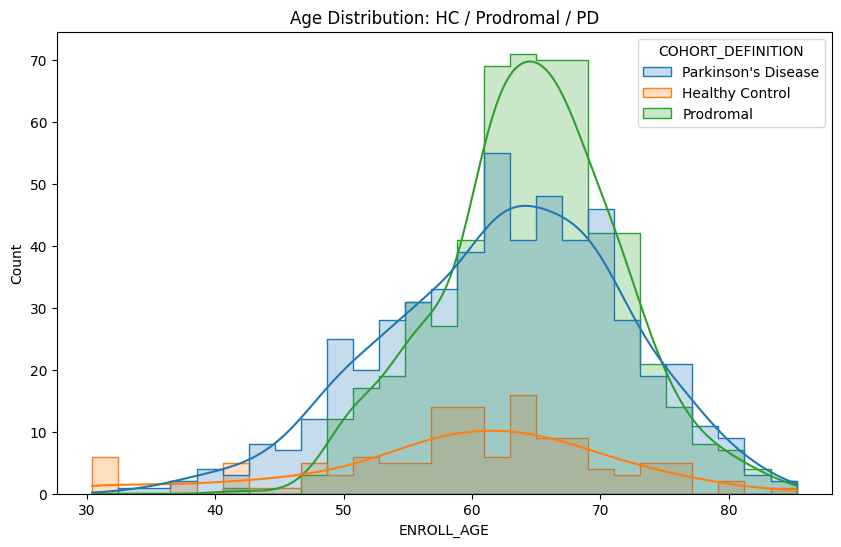

In [2]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='ENROLL_AGE', hue='COHORT_DEFINITION', kde=True, element='step')
plt.title('Age Distribution: HC / Prodromal / PD')
plt.show()

*Komentar:* HC grupa je pomaknuta prema mlađoj dobi.
Postoji značajno preklapanje, ali i jasna razlika u prosjeku.

## Step 3: Comparing Parkinson Specific Features

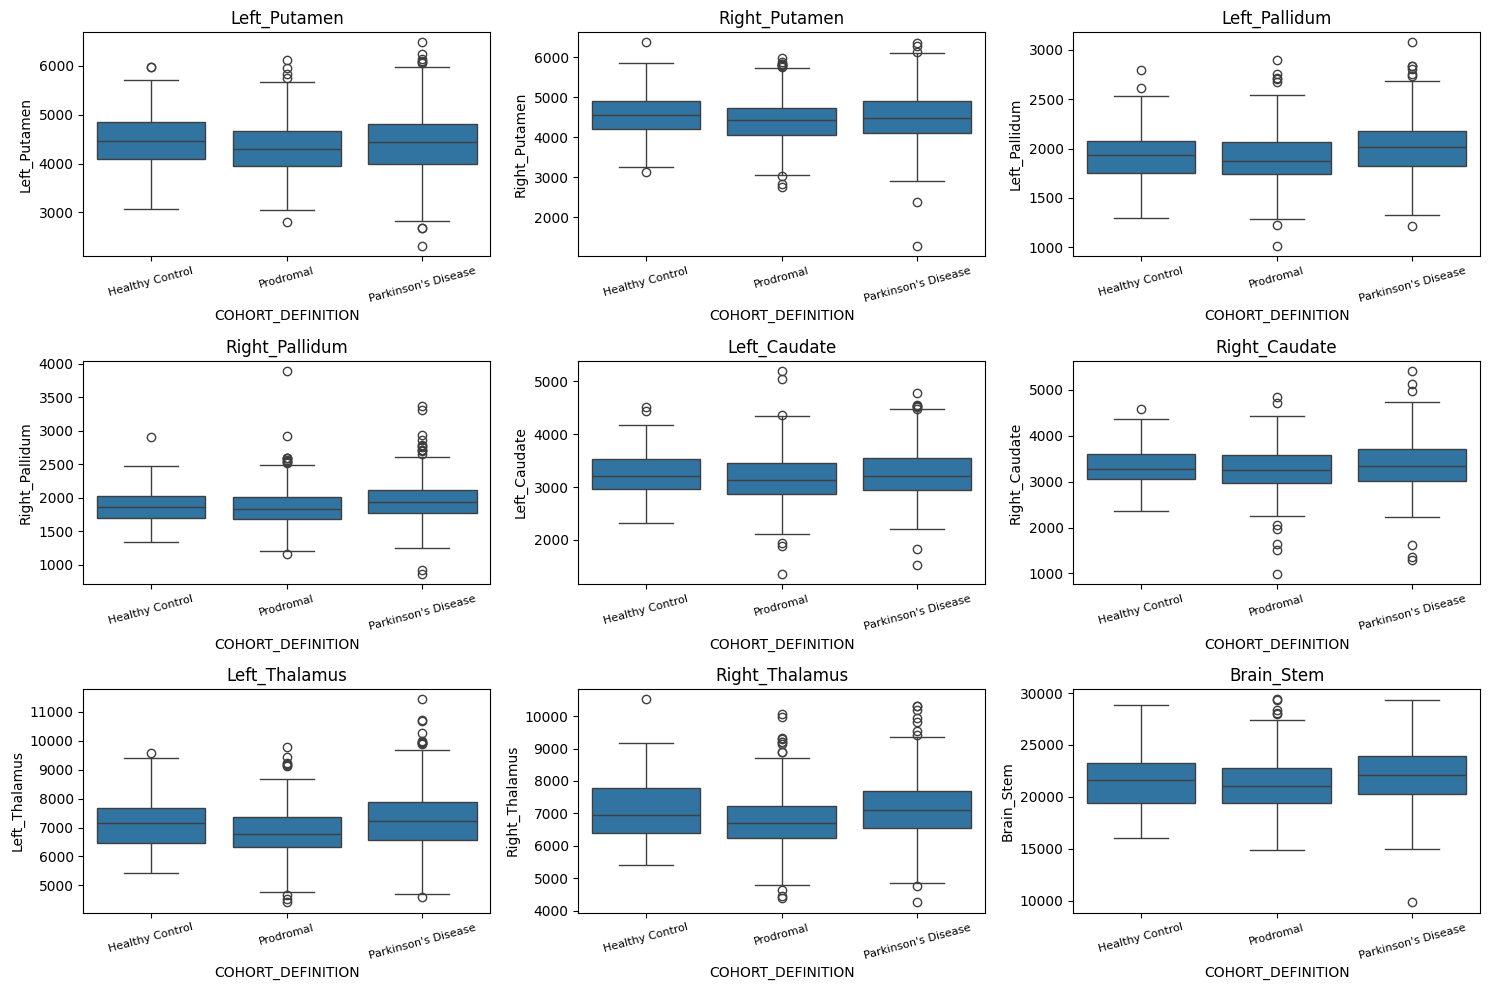

In [3]:
# parkinson specific features
parkinson_features = [
    'Left_Putamen', 'Right_Putamen',
    'Left_Pallidum', 'Right_Pallidum',
    'Left_Caudate', 'Right_Caudate',
    'Left_Thalamus', 'Right_Thalamus',
    'Brain_Stem'
]

# boxplots
plt.figure(figsize=(15, 10))

for i, region in enumerate(parkinson_features):
    if region in df.columns:
        plt.subplot(3, 3, i+1)
        sns.boxplot(data=df, x='COHORT_DEFINITION', y=region,
                    order=['Healthy Control', 'Prodromal', "Parkinson's Disease"])
        plt.title(f'{region}')
        plt.xticks(rotation=15, fontsize=8)

plt.tight_layout()
plt.show()

*Komentar:* Iz prikazanih boxplotova može se zaključiti da postoje određene razlike između grupa, ali su one relativno suptilne i uz značajno preklapanje distribucija. Kod većine regija, uključujući putamen, pallidum i caudate, vidi se blagi pomak u medijanu i povećana varijabilnost kod skupine s Parkinsonovom bolešću, što upućuje na strukturne promjene, ali ne dovoljno izražene da bi pojedinačno jasno razdvajale grupe. Najizraženiji obrazac uočava se u regiji moždanog debla, što je u skladu s poznatom ulogom tih struktura u patologiji Parkinsonova bolest. Ukupno gledano, rezultati sugeriraju da kombinacija više regija može biti informativna za razlikovanje grupa, dok pojedinačne mjere imaju ograničenu diskriminacijsku snagu.

## Step 4: Checking Statistical Significance

In [4]:
results = []

for col in df.columns:
    if col not in ['target', 'PATNO', 'COHORT_DEFINITION']:
        hc = df[df.target == 0][col].dropna()
        pd_g = df[df.target == 1][col].dropna()
        prod = df[df.target == 2][col].dropna()

        # perform one-way ANOVA test across the three groups
        stat, p = f_oneway(hc, pd_g, prod)
        results.append((col, stat, p))

# sort features by p-value (most statistically significant first)
results = sorted(results, key=lambda x: x[2])

print("Top 15 features (ANOVA, 3 groups):")
for r in results[:15]:
    print(f"  {r[0]}: F={r[1]:.3f}, p={r[2]:.2e}")

Top 15 features (ANOVA, 3 groups):
  ENROLL_AGE: F=21.633, p=5.84e-10
  BrainSegVol: F=20.822, p=1.28e-09
  Brain_Stem: F=18.554, p=1.15e-08
  MaskVol: F=14.314, p=7.16e-07
  Left_Cerebellum_Cortex: F=14.280, p=7.40e-07
  rh_parsorbitalis_sa: F=12.457, p=4.41e-06
  CC_Central: F=12.140, p=6.01e-06
  lh_insula_sa: F=11.583, p=1.04e-05
  rh_WhiteSurfArea: F=10.528, p=2.93e-05
  lh_WhiteSurfArea: F=10.472, p=3.09e-05
  rh_middletemporal_sa: F=10.027, p=4.79e-05
  rh_fusiform_sa: F=9.967, p=5.08e-05
  rh_bankssts_sa: F=9.299, p=9.81e-05
  rh_precentral_sa: F=8.855, p=1.52e-04
  rh_superiortemporal_sa: F=8.356, p=2.49e-04


*Komentar:* Rezultati sugeriraju da dataset hvata globalne strukturne razlike bolje nego specifične Parkinson-regije, što znači da bi bilo korisno normalizirati volumene (npr. po intrakranijalnom volumenu) ili analizirati relativne mjere kako bi se jasnije izolirali efekti specifični za bolest.

## Step 5: Normalization by Intracranial Volume (ICV)

In [5]:
volume_regions = [
    'Left_Putamen', 'Right_Putamen',
    'Left_Pallidum', 'Right_Pallidum',
    'Left_Caudate', 'Right_Caudate',
    'Left_Thalamus', 'Right_Thalamus',
    'Left_Lateral_Ventricle', 'Right_Lateral_Ventricle',
    'Brain_Stem'
]

norm_data = {}

for region in volume_regions:
    norm_data[region + '_norm'] = df[region] / df['EstimatedTotalIntraCranialVol']

norm_df = pd.DataFrame(norm_data)

df = pd.concat([df, norm_df], axis=1)

## Step 6: Checking for Asymetry

In [6]:
new_cols = pd.DataFrame(
    {
        'Putamen_asym': df['Left_Putamen'] - df['Right_Putamen'],
        'Caudate_asym': df['Left_Caudate'] - df['Right_Caudate'],
        'Pallidum_asym': df['Left_Pallidum'] - df['Right_Pallidum'],
        'Thalamus_asym': df['Left_Thalamus'] - df['Right_Thalamus'],
        'Lateral_Ventricle_asym': df['Left_Lateral_Ventricle'] - df['Right_Lateral_Ventricle'],
    },
    index=df.index
)

df = pd.concat([df.copy(), new_cols], axis=1)

## Step 7: Rechecking Statistical Significance

In [7]:
results = []

for col in df.columns:
    if col not in ['target', 'PATNO', 'COHORT_DEFINITION']:
        hc = df[df.target == 0][col].dropna()
        pd_g = df[df.target == 1][col].dropna()
        prod = df[df.target == 2][col].dropna()

        # perform one-way ANOVA test across the three groups
        stat, p = f_oneway(hc, pd_g, prod)
        results.append((col, stat, p))

# sort features by p-value (most statistically significant first)
results = sorted(results, key=lambda x: x[2])

print("Top 15 features (ANOVA, 3 groups):")
for r in results[:15]:
    print(f"  {r[0]}: F={r[1]:.3f}, p={r[2]:.2e}")

Top 15 features (ANOVA, 3 groups):
  Left_Thalamus: F=32.433, p=1.87e-14
  Left_Pallidum: F=23.292, p=1.18e-10
  ENROLL_AGE: F=21.633, p=5.84e-10
  BrainSegVol: F=20.822, p=1.28e-09
  Brain_Stem: F=18.554, p=1.15e-08
  Right_VentralDC: F=18.198, p=1.63e-08
  MaskVol: F=14.314, p=7.16e-07
  Left_Cerebellum_Cortex: F=14.280, p=7.40e-07
  EstimatedTotalIntraCranialVol: F=13.360, p=1.82e-06
  BrainSegVol_to_eTIV: F=12.593, p=3.85e-06
  rh_parsorbitalis_sa: F=12.457, p=4.41e-06
  CC_Central: F=12.140, p=6.01e-06
  rh_WhiteSurfArea: F=10.528, p=2.93e-05
  rh_middletemporal_sa: F=10.027, p=4.79e-05
  rh_precentral_sa: F=8.855, p=1.52e-04


In [8]:
results_df = pd.DataFrame(results, columns=['feature', 'F_stat', 'p_value'])
results_df = results_df.sort_values('p_value').reset_index(drop=True)

p_values = results_df['p_value'].tolist()
reject, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

results_df['p_corrected'] = list(p_corrected)
results_df['significant'] = list(reject)

print(f"Total no of features after FDR correction: {results_df['significant'].sum()}")
print(results_df[results_df['significant']][['feature', 'F_stat', 'p_value']].to_string())

Total no of features after FDR correction: 137
                             feature     F_stat       p_value
0                      Left_Thalamus  32.433288  1.872457e-14
1                     Right_Thalamus  27.486541  2.095090e-12
2                      Left_Pallidum  23.291511  1.177675e-10
3                     Right_Pallidum  22.280019  3.123588e-10
4                         ENROLL_AGE  21.632630  5.836362e-10
5                        BrainSegVol  20.822302  1.277466e-09
6                     SubCortGrayVol  20.295077  2.127801e-09
7                 BrainSegVolNotVent  20.279684  2.159748e-09
8                  SupraTentorialVol  19.393138  5.098272e-09
9                     Left_VentralDC  19.146013  6.478806e-09
10          SupraTentorialVolNotVent  18.769062  9.339397e-09
11                        Brain_Stem  18.554314  1.150384e-08
12                   Right_VentralDC  18.198270  1.625530e-08
13                Left_Thalamus_norm  16.681524  7.105395e-08
14            CerebralW